# Battery storage arbitrage as a linear programme

A battery buys energy when the price is low and sells when it is high. The schedule is an LP
with one twist: the state of charge links the hours together.

Everything is shown first on a **3-hour day with prices 10, 50, 30** and a 1 MW / 1 MWh battery,
then on a real day with a 50 MW / 100 MWh battery, then on all 730 days.

**What's in here**
1. The 3-hour toy: variables, cost vector, state-of-charge rows of `A_eq`, bounds, solve, read
2. Efficiency: energy is lost on the way in
3. Simultaneous charge and discharge at a negative price, and two ways to stop it
4. Cyclic vs free end state of charge
5. A builder function for any horizon, checked against the toy
6. One real day (50 MW / 100 MWh)
7. All 730 days: perfect foresight vs a heuristic vs scheduling on yesterday's prices
8. Revenue by year, sensitivity to efficiency and duration
9. Checklist

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog, milp, LinearConstraint, Bounds, minimize
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
df.head(3)

,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh
time,,,,,
2022-01-01 00:00:00+00:00,26858.4,0.11,7.00,0.0,81.83
2022-01-01 01:00:00+00:00,26177.8,-0.18,6.61,0.0,88.21
2022-01-01 02:00:00+00:00,26229.4,-1.11,7.14,0.0,84.71


## 1. The 3-hour toy

Prices 10, 50, 30 EUR/MWh. The battery can move at most 1 MW (so 1 MWh per hour) and hold at most 1 MWh.
No losses yet.

Nine variables: `charge` per hour, `discharge` per hour, `soc` (state of charge at the *end* of the hour) per hour.

In [2]:
price = np.array([10.0, 50.0, 30.0])
H = 3
P_MAX, E_MAX = 1.0, 1.0
names = ["charge_h0", "charge_h1", "charge_h2",
         "discharge_h0", "discharge_h1", "discharge_h2",
         "soc_h0", "soc_h1", "soc_h2"]
pd.Series(range(9), index=names, name="position in x")

charge_h0       0
charge_h1       1
charge_h2       2
discharge_h0    3
discharge_h1    4
discharge_h2    5
soc_h0          6
soc_h1          7
soc_h2          8
Name: position in x, dtype: int64

### The cost vector

We minimise cost. Charging 1 MWh costs the price; discharging 1 MWh earns the price, so its cost is
minus the price. `soc` costs nothing.

In [3]:
c = np.concatenate([price, -price, np.zeros(H)])
pd.Series(c, index=names, name="c")

charge_h0       10.0
charge_h1       50.0
charge_h2       30.0
discharge_h0   -10.0
discharge_h1   -50.0
discharge_h2   -30.0
soc_h0           0.0
soc_h1           0.0
soc_h2           0.0
Name: c, dtype: float64

### The state-of-charge rows of `A_eq`

Energy balance: `soc_h = soc_{h-1} + charge_h - discharge_h`, rewritten as
`soc_h - soc_{h-1} - charge_h + discharge_h = 0`.

For hour 0 there is no `soc_{-1}`. For now the battery **starts empty**, so row 0 is just
`soc_h0 - charge_h0 + discharge_h0 = 0`. (Section 4 looks at other choices.)

In [4]:
A_eq = np.array([
    # ch0 ch1 ch2  dis0 dis1 dis2  soc0 soc1 soc2
    [ -1,  0,  0,   1,   0,   0,    1,   0,   0],   # hour 0: soc0 - ch0 + dis0 = 0   (starts empty)
    [  0, -1,  0,   0,   1,   0,   -1,   1,   0],   # hour 1: soc1 - soc0 - ch1 + dis1 = 0
    [  0,  0, -1,   0,   0,   1,    0,  -1,   1],   # hour 2: soc2 - soc1 - ch2 + dis2 = 0
])
b_eq = np.zeros(H)
pd.DataFrame(A_eq, index=["hour 0", "hour 1", "hour 2"], columns=names)

,charge_h0,charge_h1,charge_h2,discharge_h0,discharge_h1,discharge_h2,soc_h0,soc_h1,soc_h2
hour 0,-1,0,0,1,0,0,1,0,0
hour 1,0,-1,0,0,1,0,-1,1,0
hour 2,0,0,-1,0,0,1,0,-1,1


Row "hour 1" says: `soc_h1 − soc_h0 − charge_h1 + discharge_h1 = 0`.

### Bounds

Charge and discharge between 0 and 1 MW; soc between 0 and 1 MWh.

In [5]:
bounds = [(0, P_MAX)] * H + [(0, P_MAX)] * H + [(0, E_MAX)] * H
pd.DataFrame(bounds, index=names, columns=["low", "high"])

,low,high
charge_h0,0,1.0
charge_h1,0,1.0
charge_h2,0,1.0
discharge_h0,0,1.0
discharge_h1,0,1.0
discharge_h2,0,1.0
soc_h0,0,1.0
soc_h1,0,1.0
soc_h2,0,1.0


### Solve and read

In [6]:
res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
print("status :", res.status, "|", res.message)
print("res.fun:", res.fun, "  -> revenue = -res.fun =", -res.fun)

status : 0 | Optimization terminated successfully. (HiGHS Status 7: Optimal)
res.fun: -40.0   -> revenue = -res.fun = 40.0


In [7]:
sched = pd.DataFrame({"price": price,
                      "charge": res.x[0:3],
                      "discharge": res.x[3:6],
                      "soc": res.x[6:9]}, index=["hour 0", "hour 1", "hour 2"])
sched

,price,charge,discharge,soc
hour 0,10.0,1.0,0.0,1.0
hour 1,50.0,0.0,1.0,0.0
hour 2,30.0,0.0,-0.0,0.0


What to notice:
- hour 0 (price 10): charge 1 MWh, soc becomes 1
- hour 1 (price 50): discharge 1 MWh, soc back to 0
- hour 2 (price 30): nothing to do, nothing left
- revenue = 50·1 − 10·1 = 40, which is `-res.fun`

Verify the balance rows by hand:

In [8]:
pd.DataFrame({"A_eq @ x": A_eq @ res.x, "b_eq": b_eq}, index=["hour 0", "hour 1", "hour 2"])

,A_eq @ x,b_eq
hour 0,0.0,0.0
hour 1,0.0,0.0
hour 2,0.0,0.0


## 2. Efficiency

Say 20% of the energy is lost on the way in: charging 1 MWh only adds 0.8 MWh to the cells.
The balance becomes `soc_h = soc_{h-1} + 0.8·charge_h - discharge_h`, so the `charge`
entries in `A_eq` change from −1 to −0.8. Everything else stays the same.

In [9]:
ETA_C = 0.8
A_eq_eff = A_eq.astype(float).copy()
A_eq_eff[:, 0:3] = A_eq_eff[:, 0:3] * ETA_C            # the charge columns
pd.DataFrame(A_eq_eff, index=["hour 0", "hour 1", "hour 2"], columns=names)

,charge_h0,charge_h1,charge_h2,discharge_h0,discharge_h1,discharge_h2,soc_h0,soc_h1,soc_h2
hour 0,-0.8,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
hour 1,0.0,-0.8,0.0,0.0,1.0,0.0,-1.0,1.0,0.0
hour 2,0.0,0.0,-0.8,0.0,0.0,1.0,0.0,-1.0,1.0


In [10]:
res_eff = linprog(c, A_eq=A_eq_eff, b_eq=b_eq, bounds=bounds, method="highs")
sched_eff = pd.DataFrame({"price": price, "charge": res_eff.x[0:3], "discharge": res_eff.x[3:6], "soc": res_eff.x[6:9]},
                         index=["hour 0", "hour 1", "hour 2"])
print("revenue:", -res_eff.fun)
sched_eff

revenue: 30.0


,price,charge,discharge,soc
hour 0,10.0,1.0,0.0,0.8
hour 1,50.0,0.0,0.8,0.0
hour 2,30.0,0.0,-0.0,0.0


Charging 1 MWh (the power limit) now gives soc 0.8, so only 0.8 MWh can be sold:
revenue = 50·0.8 − 10·1 = 30 instead of 40.

**Pitfall:** the efficiency must multiply the flow on the side where the loss happens. Writing
`soc + charge / 0.8` would *create* energy, and the solver will happily exploit it.

## 3. Simultaneous charge and discharge

Nothing in the LP forbids charging and discharging in the same hour. It only happens when it pays.
Prices **−20, −20, 50** (you are paid to consume in the first two hours), 0.8 charging loss, start empty.

Think it through: an honest battery charges 1 MWh in hour 0 (earn 20, soc 0.8), then in hour 1 only
0.2 MWh of room is left, so it charges 0.25 (earn 5) and stops: 20 + 5 + 50 = 75.
But the LP can *discharge* 0.6 MWh in hour 0 (paying 12 at the negative price) while charging the full
1 MWh (earning 20), keeping only 0.2, so that in hour 1 it can charge a full 1 MWh again (earning 20):
8 + 20 + 50 = 78. The losses are simply burnt.

In [11]:
price_neg = np.array([-20.0, -20.0, 50.0])
c_neg = np.concatenate([price_neg, -price_neg, np.zeros(H)])
res_neg = linprog(c_neg, A_eq=A_eq_eff, b_eq=b_eq, bounds=bounds, method="highs")
sched_neg = pd.DataFrame({"price": price_neg, "charge": res_neg.x[0:3], "discharge": res_neg.x[3:6], "soc": res_neg.x[6:9]},
                         index=["hour 0", "hour 1", "hour 2"])
print("revenue:", -res_neg.fun)
sched_neg

revenue: 78.0


,price,charge,discharge,soc
hour 0,-20.0,1.0,0.6,0.2
hour 1,-20.0,1.0,0.0,1.0
hour 2,50.0,0.0,1.0,0.0


Hour 0 shows charge 1.0 **and** discharge 0.6 at the same time (soc ends at 0.2, not 0.8). Physically
silly, mathematically optimal: revenue 78 instead of the honest 75.

**Fix 1: a cost per MWh of throughput** (degradation). Add `deg` to the cost of every charge
and discharge variable. It stops the churn once it exceeds the profit from burning energy.

In [12]:
for deg in [0.0, 1.0, 3.0]:
    c_deg = c_neg + deg * np.concatenate([np.ones(H), np.ones(H), np.zeros(H)])
    r = linprog(c_deg, A_eq=A_eq_eff, b_eq=b_eq, bounds=bounds, method="highs")
    both = (r.x[0:3] > 1e-6) & (r.x[3:6] > 1e-6)
    print(f"deg {deg:3.0f}: hours with simultaneous charge & discharge = {both.sum()}   "
          f"charge {r.x[0:3].round(2)}  discharge {r.x[3:6].round(2)}")

deg   0: hours with simultaneous charge & discharge = 1   charge [1. 1. 0.]  discharge [0.6 0.  1. ]
deg   1: hours with simultaneous charge & discharge = 1   charge [1. 1. 0.]  discharge [0.6 0.  1. ]
deg   3: hours with simultaneous charge & discharge = 0   charge [1.   0.25 0.  ]  discharge [0. 0. 1.]


**Fix 2: a binary mode variable** (`milp`). `mode_h = 1` means "charging allowed", 0 means "discharging
allowed": `charge_h <= P_MAX·mode_h` and `discharge_h <= P_MAX·(1 − mode_h)`.
`milp` takes constraints as `LinearConstraint(A, lower, upper)` objects and an `integrality` vector.

In [13]:
names_m = names + ["mode_h0", "mode_h1", "mode_h2"]
c_m = np.concatenate([c_neg, np.zeros(H)])
A_eq_m = np.hstack([A_eq_eff, np.zeros((H, H))])                    # balance rows, mode columns are 0
A_ch  = np.hstack([np.eye(H), np.zeros((H, 2 * H)), -P_MAX * np.eye(H)])   # charge_h - P_MAX*mode_h <= 0
A_dis = np.hstack([np.zeros((H, H)), np.eye(H), np.zeros((H, H)), P_MAX * np.eye(H)])  # discharge_h + P_MAX*mode_h <= P_MAX
pd.DataFrame(np.vstack([A_ch, A_dis]), index=["ch0", "ch1", "ch2", "dis0", "dis1", "dis2"], columns=names_m)

,charge_h0,charge_h1,charge_h2,discharge_h0,discharge_h1,discharge_h2,soc_h0,soc_h1,soc_h2,mode_h0,mode_h1,mode_h2
ch0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-0.0,-0.0
ch1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-1.0,-0.0
ch2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-1.0
dis0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
dis1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
dis2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
cons = [LinearConstraint(A_eq_m, b_eq, b_eq),
        LinearConstraint(A_ch, -np.inf, 0),
        LinearConstraint(A_dis, -np.inf, P_MAX)]
lb = np.zeros(12)
ub = np.array([P_MAX] * 6 + [E_MAX] * 3 + [1] * 3, dtype=float)
integrality = np.array([0] * 9 + [1] * 3)                 # 1 = must be integer
res_m = milp(c_m, constraints=cons, bounds=Bounds(lb, ub), integrality=integrality)
print("status:", res_m.status, "| revenue:", -res_m.fun)
pd.DataFrame({"charge": res_m.x[0:3], "discharge": res_m.x[3:6], "soc": res_m.x[6:9], "mode": res_m.x[9:12]},
             index=["hour 0", "hour 1", "hour 2"])

status: 0 | revenue: 75.0


,charge,discharge,soc,mode
hour 0,1.00,0.0,0.8,1.0
hour 1,0.25,0.0,1.0,1.0
hour 2,0.00,1.0,0.0,0.0


Hours 0 and 1 are charge-only (`mode = 1`, discharge 0), hour 2 is discharge-only; revenue is back to the
honest 75.

**Interview check:** "the schedule shows charging and discharging at 03:00, is that a bug?" Not a solver bug:
a missing constraint. Say which one and what it costs to add.

## 4. Start and end state of charge

So far the battery started empty and the end state was free, which is harmless: it starts with nothing
and leftover energy has no value, so it ends empty too.

**Starting full with a free end** is the trap. Put `soc_{-1} = 1` on the right-hand side of row 0
(`soc_h0 - 0.8·charge_h0 + discharge_h0 = 1`) and watch what happens.

In [15]:
A_eq_fix = A_eq_eff.copy()
b_eq_fix = np.array([1.0, 0.0, 0.0])     # soc_{-1} = 1: starts full
res_fix = linprog(c, A_eq=A_eq_fix, b_eq=b_eq_fix, bounds=bounds, method="highs")
print("revenue:", -res_fix.fun)
pd.DataFrame({"price": price, "charge": res_fix.x[0:3], "discharge": res_fix.x[3:6], "soc": res_fix.x[6:9]},
             index=["hour 0", "hour 1", "hour 2"])

revenue: 50.0


,price,charge,discharge,soc
hour 0,10.0,0.0,-0.0,1.0
hour 1,50.0,0.0,1.0,-0.0
hour 2,30.0,0.0,-0.0,0.0


It sells the free MWh at 50 and ends empty. Over 730 daily runs this would "earn" a free MWh every day.

The usual fix is a **cyclic** day: the battery must end the day the way it started, `soc_{-1} = soc_h2`.
In row 0 that is a −1 under `soc_h2` instead of a number on the right-hand side.

In [16]:
A_eq_cyc = A_eq_eff.copy()
A_eq_cyc[0, 8] = -1                       # row 0: soc_h0 - soc_h2 - 0.8*charge_h0 + discharge_h0 = 0
pd.DataFrame(A_eq_cyc, index=["hour 0", "hour 1", "hour 2"], columns=names)

,charge_h0,charge_h1,charge_h2,discharge_h0,discharge_h1,discharge_h2,soc_h0,soc_h1,soc_h2
hour 0,-0.8,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.0
hour 1,0.0,-0.8,0.0,0.0,1.0,0.0,-1.0,1.0,0.0
hour 2,0.0,0.0,-0.8,0.0,0.0,1.0,0.0,-1.0,1.0


In [17]:
res_cyc = linprog(c, A_eq=A_eq_cyc, b_eq=b_eq, bounds=bounds, method="highs")
print("revenue:", -res_cyc.fun)
pd.DataFrame({"price": price, "charge": res_cyc.x[0:3], "discharge": res_cyc.x[3:6], "soc": res_cyc.x[6:9]},
             index=["hour 0", "hour 1", "hour 2"])

revenue: 32.5


,price,charge,discharge,soc
hour 0,10.0,1.00,0.0,1.0
hour 1,50.0,0.00,1.0,0.0
hour 2,30.0,0.25,0.0,0.2


Revenue 32.5, not 30: the cyclic battery charges 0.25 MWh at 30 in hour 2 (cost 7.5) so that it enters
"tomorrow" with 0.2 MWh, which lets it sell a full 1.0 MWh at 50 instead of 0.8 (worth 10). That is what
"ends the day the way it started" buys you. The real-day runs below use the cyclic form.

## 5. A builder function for any horizon

The same matrices, written for H hours with a charge efficiency `eta_c` and a discharge efficiency `eta_d`
(you must draw `discharge / eta_d` from the cells to deliver `discharge`), and a `cyclic` switch.
Check it reproduces the start-empty toy exactly.

In [18]:
def build_battery(price, p_max, e_max, eta_c=1.0, eta_d=1.0, deg=0.0, cyclic=False, soc_start=0.0):
    """x = [charge(H), discharge(H), soc(H)]. Returns c, A_eq, b_eq, bounds."""
    H = len(price)
    c = np.concatenate([price + deg, -price + deg, np.zeros(H)])
    A_eq = np.zeros((H, 3 * H))
    b_eq = np.zeros(H)
    for h in range(H):
        A_eq[h, 2 * H + h] = 1              # + soc_h
        A_eq[h, h] = -eta_c                 # - eta_c * charge_h
        A_eq[h, H + h] = 1 / eta_d          # + discharge_h / eta_d
        if h > 0:
            A_eq[h, 2 * H + h - 1] = -1     # - soc_{h-1}
        elif cyclic:
            A_eq[h, 3 * H - 1] = -1         # - soc_{H-1}
        else:
            b_eq[h] = soc_start
    bounds = [(0, p_max)] * H + [(0, p_max)] * H + [(0, e_max)] * H
    return c, A_eq, b_eq, bounds

c_fn, A_fn, b_fn, bounds_fn = build_battery(price, P_MAX, E_MAX, eta_c=0.8)
print("same c     :", np.array_equal(c_fn, c))
print("same A_eq  :", np.array_equal(A_fn, A_eq_eff))
print("same bounds:", bounds_fn == bounds)

same c     : True
same A_eq  : True
same bounds: True


And a small solver that returns a readable table. Check it gives revenue 30 on the start-empty toy
and 32.5 on the cyclic one.

In [19]:
def solve_battery(price, p_max, e_max, **kw):
    c, A_eq, b_eq, bounds = build_battery(price, p_max, e_max, **kw)
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if res.status != 0:
        raise RuntimeError(res.message)
    H = len(price)
    table = pd.DataFrame({"price": price, "charge": res.x[:H], "discharge": res.x[H:2 * H], "soc": res.x[2 * H:]})
    table["revenue"] = (table["discharge"] - table["charge"]) * price
    return table, res

t, r = solve_battery(price, P_MAX, E_MAX, eta_c=0.8)
print("start empty, revenue:", -r.fun)
t_cyc, r_cyc = solve_battery(price, P_MAX, E_MAX, eta_c=0.8, cyclic=True)
print("cyclic,      revenue:", -r_cyc.fun)
t

start empty, revenue: 30.0
cyclic,      revenue: 32.5


,price,charge,discharge,soc,revenue
0,10.0,1.0,0.0,0.8,-10.0
1,50.0,0.0,0.8,0.0,40.0
2,30.0,0.0,-0.0,0.0,-0.0


## 6. One real day

50 MW / 100 MWh (a 2-hour battery), round-trip efficiency 0.85 split evenly between the two sides,
degradation 2 EUR per MWh of throughput, cyclic day. Hourly steps, so 50 MW moves at most 50 MWh per hour.

**Pitfall:** at half-hourly settlement a 50 MW limit is 25 MWh per period. Keep the time step explicit.

In [20]:
P50, E100 = 50.0, 100.0
ETA = np.sqrt(0.85)          # one-way, so round trip = 0.85
DEG = 2.0
day = "2023-02-01"
price_day = df.loc[day, "price_eur_mwh"].to_numpy()
sched_day, res_day = solve_battery(price_day, P50, E100, eta_c=ETA, eta_d=ETA, deg=DEG, cyclic=True)
print("status:", res_day.status)
print("gross revenue EUR %.0f   degradation EUR %.0f   net EUR %.0f" %
      (sched_day["revenue"].sum(), DEG * (sched_day["charge"] + sched_day["discharge"]).sum(), -res_day.fun))
sched_day.round(1).iloc[[1, 2, 3, 4, 8, 16, 17, 18, 19, 23]]

status: 0
gross revenue EUR 7436   degradation EUR 619   net EUR 6817


,price,charge,discharge,soc,revenue
1,82.6,50.0,0.0,53.9,-4127.5
2,72.8,50.0,0.0,100.0,-3642.5
3,93.4,-0.0,0.0,100.0,0.0
4,121.4,0.0,-0.0,100.0,-0.0
8,136.0,0.0,0.0,45.8,0.0
16,130.3,0.0,0.0,100.0,0.0
17,157.6,0.0,42.2,54.2,6650.8
18,169.3,0.0,50.0,-0.0,8464.0
19,147.2,0.0,0.0,-0.0,0.0
23,132.8,0.0,0.0,0.0,0.0


soc within [0, 100]: True


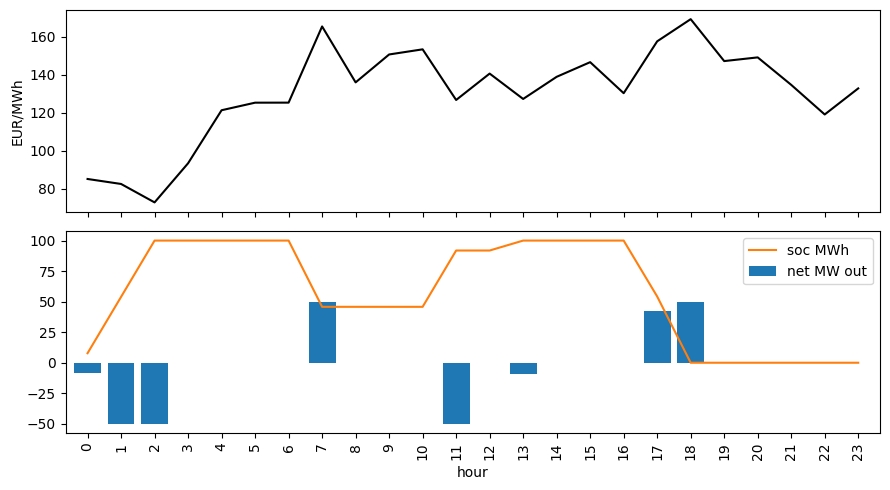

In [21]:
print("soc within [0, 100]:", (sched_day["soc"] >= -1e-6).all() and (sched_day["soc"] <= E100 + 1e-6).all())
fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
sched_day["price"].plot(ax=ax[0], color="k"); ax[0].set_ylabel("EUR/MWh")
(sched_day["discharge"] - sched_day["charge"]).plot.bar(ax=ax[1], color="tab:blue", width=0.8, label="net MW out")
ax[1].plot(sched_day["soc"].values, color="tab:orange", label="soc MWh"); ax[1].legend(); ax[1].set_xlabel("hour")
plt.tight_layout(); plt.show()

## 7. All 730 days: perfect foresight, a heuristic, and a forecast

Three ways to run the battery every day:

- **perfect foresight**: the LP on the day's actual prices (an upper bound; nobody knows prices in advance)
- **heuristic**: charge at full power in the 2 cheapest hours, discharge in the 2 dearest, executed in time order
- **forecast**: the LP on *yesterday's* prices (a naive forecast), executed against today's actual prices

First the heuristic on the 3-hour toy so you can see what "executed in time order" means.

In [22]:
price_toy = np.array([10.0, 50.0, 30.0])
n = 1                                          # E_MAX / P_MAX = number of hours to fill
order = np.argsort(price_toy)                  # hours sorted by price: [0, 2, 1]
plan_charge = np.zeros(3); plan_discharge = np.zeros(3)
plan_charge[order[:n]] = 1.0                   # cheapest hour(s)
plan_discharge[order[-n:]] = 1.0               # dearest hour(s)
pd.DataFrame({"price": price_toy, "plan_charge": plan_charge, "plan_discharge": plan_discharge})

,price,plan_charge,plan_discharge
0,10.0,1.0,0.0
1,50.0,0.0,1.0
2,30.0,0.0,0.0


Then execute the plan hour by hour, clipping to what the state of charge allows (you cannot discharge
more than you hold, or charge beyond the capacity). Here the plan is feasible and earns 40.

In [23]:
soc = 0.0
revenue = 0.0
for h in range(3):
    ch = min(plan_charge[h], 1.0 - soc)        # room left in the battery
    dis = min(plan_discharge[h], soc)          # energy available
    soc = soc + ch - dis
    revenue = revenue + (dis - ch) * price_toy[h]
    print(f"hour {h}: charge {ch:.1f}  discharge {dis:.1f}  soc {soc:.1f}  revenue so far {revenue:.0f}")

hour 0: charge 1.0  discharge 0.0  soc 1.0  revenue so far -10
hour 1: charge 0.0  discharge 1.0  soc 0.0  revenue so far 40
hour 2: charge 0.0  discharge 0.0  soc 0.0  revenue so far 40


The same two steps as functions (with efficiency and degradation), then the loop over all complete days.

In [24]:
def heuristic_plan(price, p_max, e_max):
    n = int(e_max / p_max)
    order = np.argsort(price)
    ch = np.zeros(len(price)); dis = np.zeros(len(price))
    ch[order[:n]] = p_max
    dis[order[-n:]] = p_max
    return ch, dis

def execute(price, plan_charge, plan_discharge, e_max, eta, deg):
    soc, revenue = 0.0, 0.0
    for h in range(len(price)):
        ch = min(plan_charge[h], (e_max - soc) / eta)
        dis = min(plan_discharge[h], soc * eta)
        soc = soc + eta * ch - dis / eta
        revenue = revenue + (dis - ch) * price[h] - deg * (ch + dis)
    return revenue

prices = df["price_eur_mwh"]
complete = prices.resample("D").size()
days = complete[complete == 24].index
P = np.stack([prices.loc[str(d.date())].to_numpy() for d in days])     # (n_days, 24)
print("days:", P.shape[0])

days: 730


In [25]:
rows = []
for i, d in enumerate(days):
    p = P[i]
    _, r_pf = solve_battery(p, P50, E100, eta_c=ETA, eta_d=ETA, deg=DEG, cyclic=True)
    perfect = -r_pf.fun
    heur = execute(p, *heuristic_plan(p, P50, E100), E100, ETA, DEG)
    if i > 0:
        s_fc, _ = solve_battery(P[i - 1], P50, E100, eta_c=ETA, eta_d=ETA, deg=DEG, cyclic=True)    # plan on yesterday
        fc = ((s_fc["discharge"] - s_fc["charge"]) * p).sum() - DEG * (s_fc["charge"] + s_fc["discharge"]).sum()
    else:
        fc = np.nan
    rows.append((d, perfect, heur, fc, p.max() - p.min()))
daily = pd.DataFrame(rows, columns=["day", "perfect", "heuristic", "forecast", "spread"]).set_index("day")
daily.head()

,perfect,heuristic,forecast,spread
day,,,,
2022-01-01 00:00:00+00:00,6993.332438,4266.80,NaN,68.50
2022-01-02 00:00:00+00:00,10352.009674,3010.80,2044.231642,143.33
2022-01-03 00:00:00+00:00,6076.748633,5368.05,3361.482863,80.19
2022-01-04 00:00:00+00:00,8052.350792,7032.35,5563.268119,106.83
2022-01-05 00:00:00+00:00,15254.087682,11904.95,2934.854526,258.52


In [26]:
total = daily[["perfect", "heuristic", "forecast"]].sum()
print((total / 1e6).round(2).rename("EUR m over 2 years"))
print()
print("heuristic captures %.0f%% of perfect foresight" % (100 * total["heuristic"] / total["perfect"]))
print("yesterday's-price schedule captures %.0f%%" % (100 * total["forecast"] / total["perfect"]))
print("days where the forecast schedule lost money:", int((daily["forecast"] < 0).sum()))

perfect      6.11
heuristic    3.78
forecast     1.73
Name: EUR m over 2 years, dtype: float64

heuristic captures 62% of perfect foresight
yesterday's-price schedule captures 28%
days where the forecast schedule lost money: 129


The forecast-based number is what a desk would actually have earned. The gap to perfect foresight is
the value of a better price forecast.

**Interview check:** "what would you work on to close the gap?" The *shape* of the price forecast
(which hours are cheap and dear), not the level: a battery does not care about the level.

## 8. Revenue by year, and sensitivity

Arbitrage revenue follows the intraday **spread**, not the price level. Check by year before quoting an
annual figure.

In [27]:
by_year = daily[["perfect", "forecast"]].groupby(daily.index.year).sum() / 1e6
print(by_year.round(2).rename(columns=lambda s: s + " (EUR m)"))
print("correlation of daily revenue with daily spread: %.2f" % daily[["perfect", "spread"]].corr().iloc[0, 1])

      perfect (EUR m)  forecast (EUR m)
day                                    
2022             2.86              0.73
2023             3.25              0.99
correlation of daily revenue with daily spread: 0.85


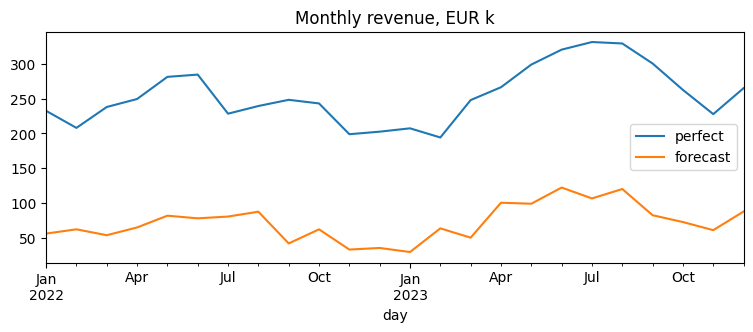

In [28]:
(daily[["perfect", "forecast"]].resample("MS").sum() / 1e3).plot(figsize=(9, 3), title="Monthly revenue, EUR k")
plt.show()

Same LP on 2023 with different efficiency and duration (`E_MAX / P_MAX`). A 1-hour battery can only
use one cheap and one dear hour; a 4-hour battery uses four, at the same power.

In [29]:
P23 = P[np.array([d.year == 2023 for d in days])]
table = {}
for dur in [1, 2, 4]:
    for rt in [0.75, 0.85, 0.95]:
        eta = np.sqrt(rt)
        rev = 0.0
        for p in P23:
            rev = rev - solve_battery(p, P50, P50 * dur, eta_c=eta, eta_d=eta, deg=DEG, cyclic=True)[1].fun
        table[(f"{dur}h", rt)] = rev / 1e6
sens = pd.Series(table).unstack()
sens.index.name = "duration"; sens.columns.name = "round-trip efficiency"
print("2023 perfect-foresight revenue, EUR m")
sens.round(2)

2023 perfect-foresight revenue, EUR m


round-trip efficiency,0.75,0.85,0.95
duration,,,
1h,1.65,2.12,2.74
2h,2.53,3.25,4.12
4h,3.54,4.62,5.82


Revenue per extra hour of storage falls: the fourth hour is worth less than the second. That is the
number a capital-allocation decision hinges on.

## 9. Checklist

1. Write the balance row for one hour by hand; check the sign of every term.
2. Put the efficiency on the side where the loss happens; a wrong side creates free energy.
3. Decide the boundary: cyclic, fixed end, or a value for leftover energy. Never leave it free.
4. `linprog` minimises: cost = price·charge − price·discharge (+ degradation). Check on one hour.
5. Look for simultaneous charge/discharge; decide between a throughput cost and a binary.
6. Perfect foresight is an upper bound. Report the forecast-based number too.
7. Revenue follows the spread; check by year before quoting an annual figure.
8. Report sensitivity to efficiency and duration.